In [2]:
from pathlib import Path

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parent

df = pd.read_csv(
    PROJECT_ROOT / "data" / "raw" / "Telco-Customer-Churn.csv"
)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce",
)

df = df.dropna(subset=["TotalCharges"])
df = df.drop_duplicates(subset=["customerID"])

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0,
})

In [5]:
from sklearn.model_selection import train_test_split

TARGET = "Churn"

X = df.drop(columns=["customerID", TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


In [6]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

C:\Users\hp\AppData\Local\Temp\ipykernel_30432\479890644.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [7]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

In [8]:
y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(
    X_test
)[:, 1]

In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [11]:
from src.evaluate import evaluate_model

logistic_results = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

print(logistic_results)

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

{'Accuracy': 0.7256574271499645, 'Precision': 0.4901315789473684, 'Recall': 0.7967914438502673, 'F1': 0.6069246435845214, 'ROC-AUC': 0.8351344145860403}


Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=6,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

XGBoost

In [14]:
from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42
            )
        )
    ]
)

LightGBM

In [15]:
from lightgbm import LGBMClassifier

lightgbm_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LGBMClassifier(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=-1,
                num_leaves=31,
                random_state=42,
                verbosity=-1
            )
        )
    ]
)

Train All Models

In [16]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "XGBoost": xgb_model,
    "LightGBM": lightgbm_model
}

results = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train,
        y_train
    )

    results[name] = evaluate_model(
        model,
        X_test,
        y_test
    )


Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407


Training Decision Tree...
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.73      0.75      1407


Training Random Forest...
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1033
           1       0.55      0.65      0.59       374

    accuracy                           0.76      1407
   macro avg       0.71      0.73      0.

Compare Models

In [17]:
results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    "ROC-AUC",
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.725657,0.490132,0.796791,0.606925,0.835134
XGBoost,0.779673,0.596386,0.529412,0.560907,0.821851
Decision Tree,0.733475,0.499165,0.799465,0.614594,0.818165
LightGBM,0.769012,0.574468,0.505348,0.537696,0.817214
Random Forest,0.764748,0.548533,0.649733,0.594859,0.816146


Visualize:

In [19]:
import matplotlib.pyplot as plt

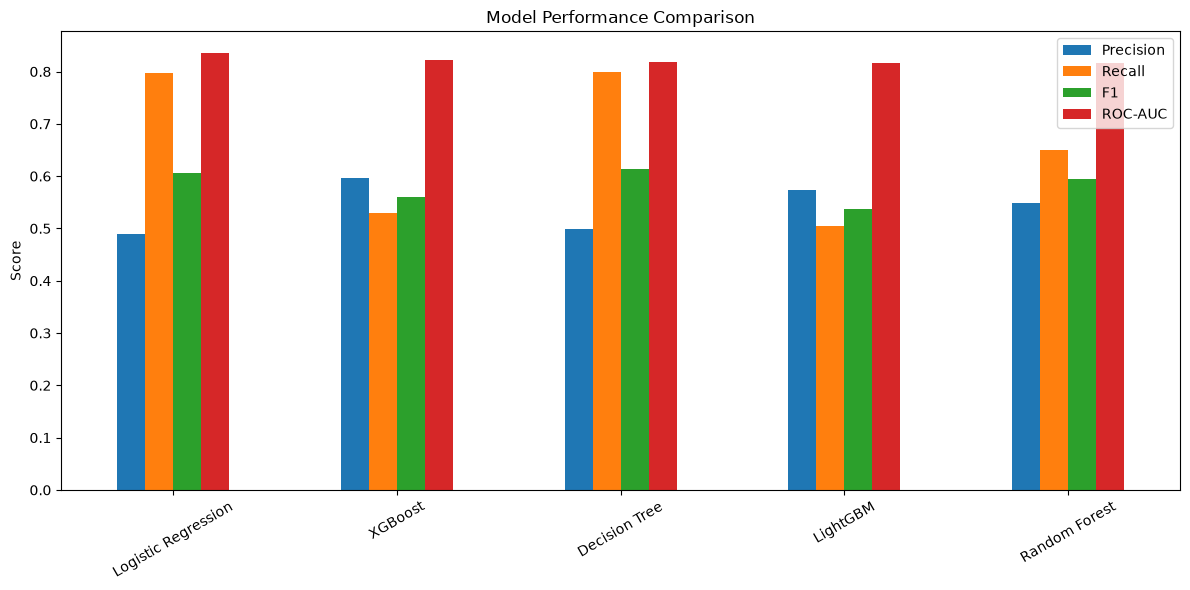

In [20]:
results_df[
    ["Precision", "Recall", "F1", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

Confusion Matrix

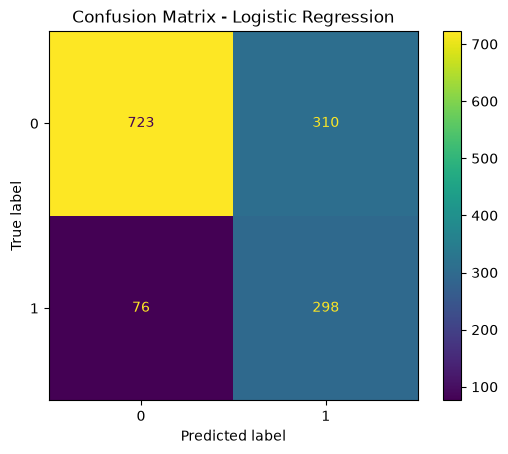

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = models[
    results_df.index[0]
]

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title(
    f"Confusion Matrix - {results_df.index[0]}"
)

plt.show()

ROC Curve

<Figure size 800x600 with 0 Axes>

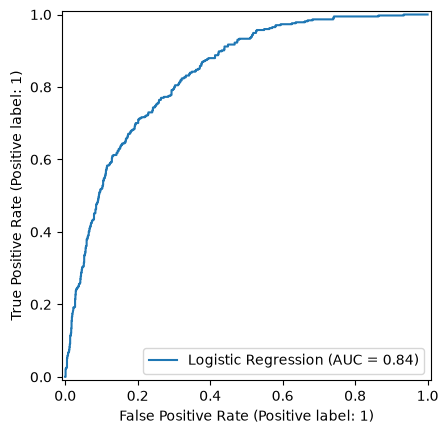

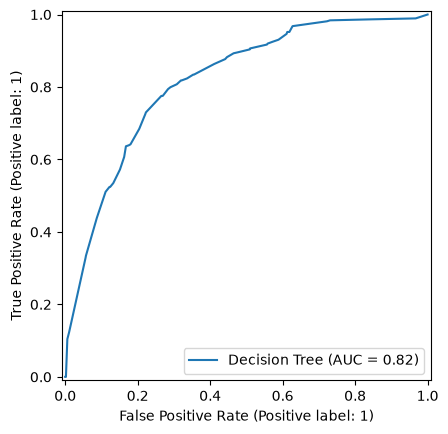

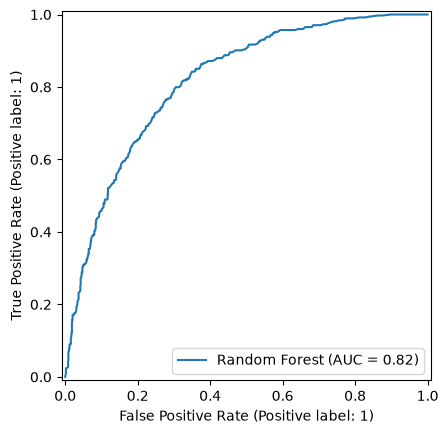

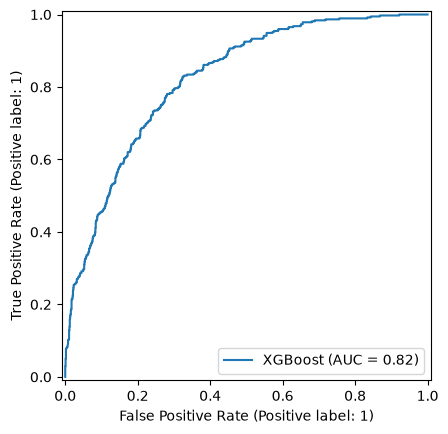

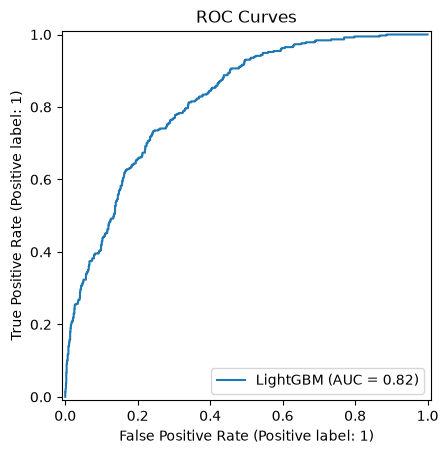

In [22]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

for name, model in models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.title("ROC Curves")
plt.show()

Hyperparameter Tuning

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [
        200,
        400,
        600
    ],

    "model__max_depth": [
        3,
        5,
        7
    ],

    "model__learning_rate": [
        0.01,
        0.05,
        0.1
    ]
}

In [24]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [200, 400, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_exampl

In [25]:
print(
    grid_search.best_params_
)

print(
    grid_search.best_score_
)

{'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 600}
0.8491914128612728


Save Model

In [27]:
from pathlib import Path
import joblib

PROJECT_ROOT = Path.cwd().resolve().parent

model_path = PROJECT_ROOT / "models" / "churn_model.joblib"
model_path.parent.mkdir(parents=True, exist_ok=True)

final_model = grid_search.best_estimator_

joblib.dump(final_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: C:\Users\hp\Documents\GitHub\Customer-Churn-Prediction-System\models\churn_model.joblib


In [29]:
metadata_path = PROJECT_ROOT / "models" / "model_metadata.joblib"

metadata = {
    "model": "XGBoost",
    "target": "Churn",
    "random_state": 42,
}

joblib.dump(metadata, metadata_path)

['C:\\Users\\hp\\Documents\\GitHub\\Customer-Churn-Prediction-System\\models\\model_metadata.joblib']

In [37]:
from pathlib import Path
import joblib

model_path = Path("../models/churn_model.joblib")
model_path.parent.mkdir(parents=True, exist_ok=True)

final_model = grid_search.best_estimator_

joblib.dump(final_model, model_path)

print("Model saved to:", model_path.resolve())

Model saved to: C:\Users\hp\Documents\GitHub\Customer-Churn-Prediction-System\models\churn_model.joblib


In [38]:
saved_model = joblib.load(model_path)

print(
    saved_model.named_steps["model"].__class__.__name__
)

XGBClassifier


In [39]:
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

In [36]:
import joblib

final_model = grid_search.best_estimator_

joblib.dump(
    final_model,
    "models/churn_model.joblib"
)

FileNotFoundError: [Errno 2] No such file or directory: 'models/churn_model.joblib'

In [31]:
metadata = {
    "model": "XGBoost",
    "target": "Churn",
    "random_state": 42
}

joblib.dump(
    metadata,
    "models/model_metadata.joblib"
)

FileNotFoundError: [Errno 2] No such file or directory: 'models/model_metadata.joblib'

In [40]:
import shap

model = final_model.named_steps["model"]
processor = final_model.named_steps["preprocessor"]

X_test_processed = processor.transform(X_test)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_test_processed
)

In [41]:
feature_names = (
    processor
    .get_feature_names_out()
)

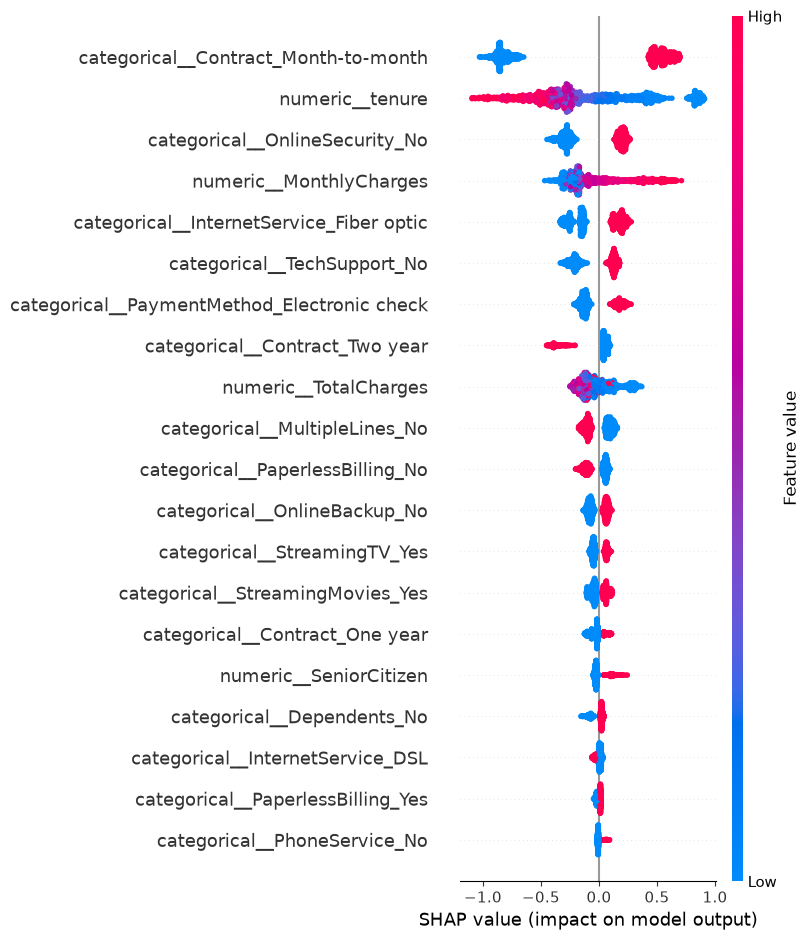

In [42]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

In [44]:
customer = X_test.iloc[[0]]

prediction = final_model.predict(
    customer
)[0]

probability = final_model.predict_proba(
    customer
)[0, 1]

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: 0
Probability: 0.026219532


In [46]:
prediction = final_model.predict(X_test)[0]
probability = final_model.predict_proba(X_test)[0, 1]

print(
    f"Churn Prediction: "
    f"{'Yes' if prediction == 1 else 'No'}"
)

print(
    f"Churn Probability: "
    f"{probability:.2%}"
)

if probability >= 0.70:
    risk = "High"
elif probability >= 0.40:
    risk = "Medium"
else:
    risk = "Low"

print(f"Risk Level: {risk}")

Churn Prediction: No
Churn Probability: 2.62%
Risk Level: Low
